In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import numpy as np

sns.set(style="whitegrid")

In [2]:
DATASET_CSV = "/Users/roy-siftt/final-project/datasets/document_type_classification/dataset.csv"   # Change this if needed

df = pd.read_csv(DATASET_CSV)
df.head()

,image_path,label
0,images/07941.png,driver_license
1,images/01163.png,passport
2,images/00583.png,passport
3,images/04082.png,id_card
4,images/08413.png,driver_license


In [3]:
print("Total rows in dataset:", len(df))
print("\nColumn names:", df.columns.tolist())
df.info()

Total rows in dataset: 9000

Column names: ['image_path', 'label']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  9000 non-null   object
 1   label       9000 non-null   object
dtypes: object(2)
memory usage: 140.8+ KB


/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_37530/3384659074.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="coolwarm")


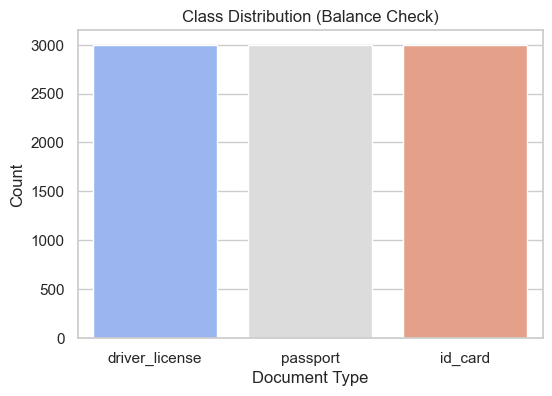

Label counts:
label
driver_license    3000
passport          3000
id_card           3000
Name: count, dtype: int64

Balance Ratio: 1.0
✔ The dataset is well-balanced (excellent).


In [4]:
# ===============================================
# 📊  Balance Analysis: Is the dataset balanced?
# ===============================================

label_counts = df['label'].value_counts()
total = len(df)

plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="coolwarm")
plt.title("Class Distribution (Balance Check)")
plt.xlabel("Document Type")
plt.ylabel("Count")
plt.show()

print("Label counts:")
print(label_counts)

# Balance ratio: lowest_class / highest_class
balance_ratio = label_counts.min() / label_counts.max()

print("\nBalance Ratio:", round(balance_ratio, 3))

if balance_ratio > 0.9:
    print("✔ The dataset is well-balanced (excellent).")
elif balance_ratio > 0.7:
    print("✔ The dataset is moderately balanced (acceptable).")
else:
    print("⚠ The dataset is imbalanced — consider balancing techniques.")

In [5]:
plt.figure(figsize=(7,4))
df['country'].value_counts().plot(kind='bar', color='salmon')
plt.title("Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

df['country'].value_counts()

KeyError: 'country'

<Figure size 700x400 with 0 Axes>

/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_62313/940753647.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.values, y=top_sources.index, palette="viridis")


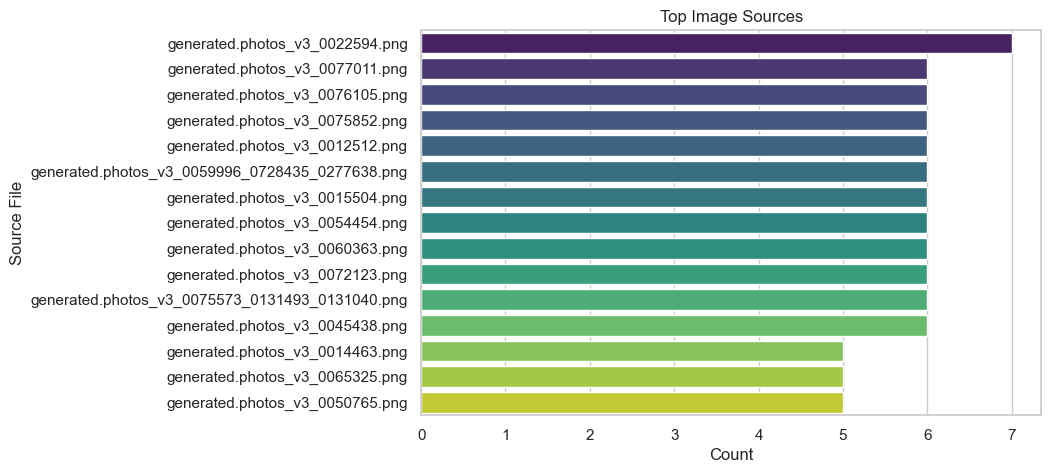

In [ ]:
top_sources = df['source_file'].value_counts().head(15)

plt.figure(figsize=(8,5))
sns.barplot(x=top_sources.values, y=top_sources.index, palette="viridis")
plt.title("Top Image Sources")
plt.xlabel("Count")
plt.ylabel("Source File")
plt.show()

In [ ]:
missing = []

for path in df['image_path']:
    if not os.path.exists(path):
        missing.append(path)

print("Missing images:", len(missing))

if missing:
    print("Examples of missing paths:", missing[:10])
else:
    print("All images exist — dataset is clean.")

Missing images: 5400
Examples of missing paths: ['images/00001.png', 'images/00002.png', 'images/00003.png', 'images/00004.png', 'images/00005.png', 'images/00006.png', 'images/00007.png', 'images/00008.png', 'images/00009.png', 'images/00010.png']


In [ ]:
widths = []
heights = []

sample_paths = df['/Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/images'].sample(min(300, len(df)))

for p in sample_paths:
    try:
        img = Image.open(p)
        w, h = img.size
        widths.append(w)
        heights.append(h)
    except:
        pass

plt.figure(figsize=(8,5))
plt.scatter(widths, heights, alpha=0.5)
plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

KeyError: '/Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/images'

In [ ]:
import random

labels = df['label'].unique()

for label in labels:
    subset = df[df['label'] == label].sample(3)
    
    plt.figure(figsize=(10,4))
    plt.suptitle(f"Samples for Label: {label}", fontsize=14)

    for i, (_, row) in enumerate(subset.iterrows()):
        img = Image.open(row['image_path'])
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/roy-siftt/final-project/notebooks/images/02791.png'

<Figure size 1000x400 with 0 Axes>

In [ ]:
print("===== DATASET QUALITY SUMMARY =====\n")

print("✔ Total images:", len(df))
print("✔ Unique labels:", df['label'].nunique())
print("✔ Unique countries:", df['country'].nunique())
print("✔ Missing images:", len(missing))

print("\nLabel distribution:")
print(df['label'].value_counts())

print("\nCountry distribution:")
print(df['country'].value_counts())

print("\nEverything looks ready for splitting and training!")

===== DATASET QUALITY SUMMARY =====

✔ Total images: 5400
✔ Unique labels: 3
✔ Unique countries: 9
✔ Missing images: 5400

Label distribution:
label
passport          1800
id_card           1800
driver_license    1800
Name: count, dtype: int64

Country distribution:
country
GRC    600
RUS    600
WV     600
LVA    600
SVK    600
AZ     600
ALB    600
NV     600
DC     600
Name: count, dtype: int64

Everything looks ready for splitting and training!
